# RUL Prediction: Hybrid Transformer Models
## LSTM-Transformer, GRU-Transformer, CNN-Transformer Architectures
**Owen's Implementation - Team Deep Learning Project**

# FD001 Dataset - RUL Prediction with Hybrid Transformers

In [23]:
import os
import csv
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

def seed_everything(seed=None):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [4]:
# If running in Colab, authenticate and mount Google Drive

# from google.colab import auth
# auth.authenticate_user()


## Part 1: Exploratory Data Analysis (EDA)

In [11]:
### Local paths to the processed NASA datasets ###

# Data Cleaning 1: RUL only, no feature engineering, normalization
train_df_fd001_rul = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_1/train_processed_rul_only_fd001.csv')
test_df_fd001_rul = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_1/test_processed_rul_only_fd001.csv')

# Data Cleaning 2: RUL only, no feature engineering, no normalization
train_df_fd001_nonorm = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_no_norm_0/train_processed_rul_only_fd001.csv')
test_df_fd001_nonorm = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_no_norm_0/test_processed_rul_only_fd001.csv')

# Data Cleaning 3: Piecewise RUL, no feature engineering, normalization (capped at 150)
train_df_fd001_piecewise = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/train_processed_rul_piecewise_150_fd001.csv')
test_df_fd001_piecewise = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/test_processed_rul_piecewise_150_fd001.csv')

# Feature Engineering 2: Feature engineered using High Correlation (Manual) method, normalization (drop s14)
train_df_fd001_fe_manual_drop_s14 = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/train_fd001_drop_s14.csv')
test_df_fd001_fe_manual_drop_s14 = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/test_fd001_drop_s14.csv')

# Feature Engineering 2: Feature engineered using High Correlation (Manual) method, normalization (drop s14 and s12)
train_df_fd001_fe_manual_drop_s14_s12 = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/train_fd001_drop_s14_s12.csv')
test_df_fd001_fe_manual_drop_s14_s12 = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/test_fd001_drop_s14_s12.csv')

# Feature Engineering 2: Feature engineered using High Correlation (Manual) method, normalization (drop s14 and s11)
train_df_fd001_fe_manual_drop_s14_s11 = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/train_fd001_drop_s14_s11.csv')
test_df_fd001_fe_manual_drop_s14_s11 = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/test_fd001_drop_s14_s11.csv')

# Feature Engineering 2: Feature engineered using Low Variance method, normalization
train_df_fd001_fe_lowvar = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/low_variance_1/train_fd001_low_variance_1.csv')
test_df_fd001_fe_lowvar = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/low_variance_1/test_fd001_low_variance_1.csv')

eda_data = []
datasets = [
    ("Linear RUL (No Norm)", train_df_fd001_nonorm, test_df_fd001_nonorm),
    ("Linear RUL (Normalized)", train_df_fd001_rul, test_df_fd001_rul),
    ("Piecewise RUL (150)", train_df_fd001_piecewise, test_df_fd001_piecewise),
    ("FE - Low Variance", train_df_fd001_fe_lowvar, test_df_fd001_fe_lowvar),
    ("FE - Manual (High Corr - Drop s14)", train_df_fd001_fe_manual_drop_s14, test_df_fd001_fe_manual_drop_s14),
    ("FE - Manual (High Corr - Drop s14, s11)", train_df_fd001_fe_manual_drop_s14_s11, test_df_fd001_fe_manual_drop_s14_s11),
    ("FE - Manual (High Corr - Drop s14, s12)", train_df_fd001_fe_manual_drop_s14_s12, test_df_fd001_fe_manual_drop_s14_s12),
]

for name, train_df, test_df in datasets:
    eda_data.append({
        'Dataset': name,
        'Train Rows': f"{train_df.shape[0]:,}",
        'Test Rows': f"{test_df.shape[0]:,}",
        'Features': train_df.shape[1],
        'Engines (Train)': train_df['id'].nunique(),
        'Engines (Test)': test_df['id'].nunique(),
        'RUL Range': f"[{train_df['RUL'].min()}, {train_df['RUL'].max()}]",
    })

eda_df = pd.DataFrame(eda_data)
print("\n" + "="*110)
print(eda_df.to_string(index=False))
print("="*110 + "\n")


                                Dataset Train Rows Test Rows  Features  Engines (Train)  Engines (Test) RUL Range
                   Linear RUL (No Norm)     20,631    13,096        27              100             100  [0, 361]
                Linear RUL (Normalized)     20,631    13,096        27              100             100  [0, 361]
                    Piecewise RUL (150)     20,631    13,096        27              100             100  [0, 150]
                      FE - Low Variance     20,631    13,096        20              100             100  [0, 150]
     FE - Manual (High Corr - Drop s14)     20,631    13,096        19              100             100  [0, 150]
FE - Manual (High Corr - Drop s14, s11)     20,631    13,096        18              100             100  [0, 150]
FE - Manual (High Corr - Drop s14, s12)     20,631    13,096        18              100             100  [0, 150]



### Simple EDA on the RUL dataset to understand the data distribution, feature importance, and potential correlations.

/var/folders/59/qbzfw51d345c84sls3kvv_300000gn/T/ipykernel_19437/1090234136.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(rul_data, labels=dataset_names, patch_artist=True)


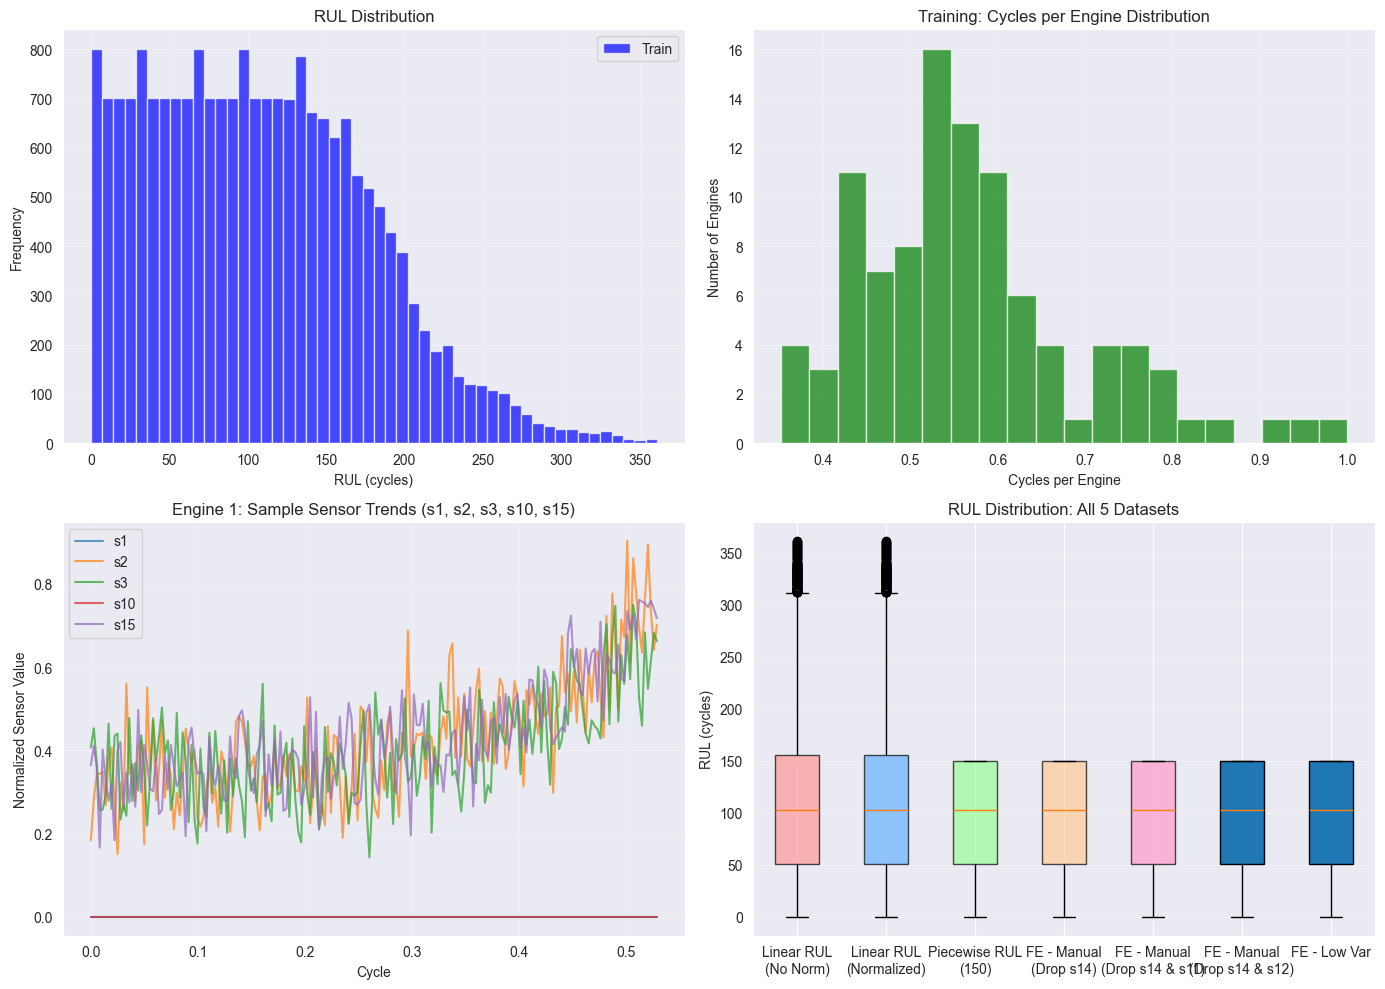

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RUL Distribution
axes[0, 0].hist(train_df_fd001_rul['RUL'], bins=50, alpha=0.7, color='blue', label='Train')
axes[0, 0].set_xlabel('RUL (cycles)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('RUL Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Cycles per Engine
train_cycles_dist = train_df_fd001_rul.groupby('id')['cycle'].max()
axes[0, 1].hist(train_cycles_dist, bins=20, color='green', alpha=0.7)
axes[0, 1].set_xlabel('Cycles per Engine')
axes[0, 1].set_ylabel('Number of Engines')
axes[0, 1].set_title('Training: Cycles per Engine Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sample sensor trends (Engine 1)
engine1_data = train_df_fd001_rul[train_df_fd001_rul['id'] == 1].sort_values('cycle')
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s1'], label='s1', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s2'], label='s2', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s3'], label='s3', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s10'], label='s10', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s15'], label='s15', alpha=0.7)
axes[1, 0].set_xlabel('Cycle')
axes[1, 0].set_ylabel('Normalized Sensor Value')
axes[1, 0].set_title('Engine 1: Sample Sensor Trends (s1, s2, s3, s10, s15)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. RUL Distribution Box Plot across all 7 datasets
rul_data = [
    train_df_fd001_nonorm['RUL'].values,
    train_df_fd001_rul['RUL'].values,
    train_df_fd001_piecewise['RUL'].values,
    train_df_fd001_fe_manual_drop_s14['RUL'].values,
    train_df_fd001_fe_manual_drop_s14_s11['RUL'].values,
    train_df_fd001_fe_manual_drop_s14_s12['RUL'].values,
    train_df_fd001_fe_lowvar['RUL'].values,
]

dataset_names = [
    'Linear RUL\n(No Norm)',
    'Linear RUL\n(Normalized)',
    'Piecewise RUL\n(150)',
    'FE - Manual\n(Drop s14)',
    'FE - Manual\n(Drop s14 & s11)',
    'FE - Manual\n(Drop s14 & s12)',
    'FE - Low Var',
]

bp = axes[1, 1].boxplot(rul_data, labels=dataset_names, patch_artist=True)

# Customize box plot colors
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 1].set_ylabel('RUL (cycles)')
axes[1, 1].set_title('RUL Distribution: All 5 Datasets')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Part 2: Data Preparation & Sequence Creation

**Why do we need to create sequences for RUL prediction?**
- RUL prediction is a time-series forecasting problem where we want to predict the remaining useful life of a machine based on its historical sensor readings.
- Thus, we **cannot treat each data point independently or randomly shuffle the data,** as we would in a typical supervised learning problem.
- Creating sequences allows us to capture temporal dependencies and patterns in the data, which are crucial for accurate RUL prediction.
- By feeding sequences of sensor readings into our models, we can learn how the machine's condition evolves over time and make more informed predictions about its future state.
- In the next steps, we will preprocess the data, create sequences of sensor readings, and prepare the datasets for training our hybrid transformer models.

In [25]:
### Dataset and DataLoader Creation for Multi-Seed Training ###

# Define seeds to test
SEEDS = [1234, 42, 999]

SEQUENCE_LENGTH = 50
BATCH_SIZE = 64
TRAIN_TEST_SPLIT = 0.8  # 80% of training data for training, 20% for validation

class RULDataset(Dataset):
    """PyTorch Dataset for RUL sequence prediction"""
    def __init__(self, df, sequence_length=30, feature_cols=None):
        """
        Args:
            df: DataFrame with columns: id, cycle, feature_cols, and RUL
            sequence_length: Length of input sequences
            feature_cols: List of feature column names (auto-detected if None)
        """
        self.sequence_length = sequence_length
        
        # Auto-detect feature columns if not provided
        if feature_cols is None:
            self.feature_cols = [col for col in df.columns if col[0] == 's' and col[1:].isdigit()]
        else:
            self.feature_cols = feature_cols
            
        self.sequences = []
        self.labels = []
        
        # Create sequences per engine
        for engine_id in df['id'].unique():
            engine_data = df[df['id'] == engine_id].sort_values('cycle').reset_index(drop=True)
            features = engine_data[self.feature_cols].values
            rul = engine_data['RUL'].values
            
            # Create overlapping sequences
            for i in range(len(engine_data) - sequence_length):
                self.sequences.append(features[i:i+sequence_length])
                self.labels.append(rul[i+sequence_length])

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.float32)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx]), torch.tensor(self.labels[idx])

# Dictionary to store all datasets
datasets_config = {
    'Linear RUL (No Norm)': (train_df_fd001_nonorm, test_df_fd001_nonorm),
    'Linear RUL (Normalized)': (train_df_fd001_rul, test_df_fd001_rul),
    'Piecewise RUL (150)': (train_df_fd001_piecewise, test_df_fd001_piecewise),
    'FE - Manual (Drop s14)': (train_df_fd001_fe_manual_drop_s14, test_df_fd001_fe_manual_drop_s14),
    'FE - Manual (Drop s14, s12)': (train_df_fd001_fe_manual_drop_s14_s12, test_df_fd001_fe_manual_drop_s14_s12),
    'FE - Manual (Drop s14, s11)': (train_df_fd001_fe_manual_drop_s14_s11, test_df_fd001_fe_manual_drop_s14_s11),
    'FE - Low Variance': (train_df_fd001_fe_lowvar, test_df_fd001_fe_lowvar),
}

# ============ CREATE BASE DATASETS ONCE (seed-independent) ============
print("\n" + "="*130)
print("Creating BASE DATASETS (seed-independent)")
print("="*130)

base_datasets = {}
test_datasets = {}

for dataset_name, (train_df, test_df) in datasets_config.items():
    base_datasets[dataset_name] = RULDataset(train_df, SEQUENCE_LENGTH)
    test_datasets[dataset_name] = RULDataset(test_df, SEQUENCE_LENGTH)
    print(f"✓ {dataset_name}: train={len(base_datasets[dataset_name])}, test={len(test_datasets[dataset_name])}")

print(f"\nCreated {len(base_datasets)} base datasets")

# ============ CREATE LOADERS FOR EACH SEED ============
# Structure: {seed: {dataset_name: {'train': loader, 'val': loader, 'test': loader}}}
loaders_by_seed = {}

for seed in SEEDS:
    print(f"\n{'='*130}")
    print(f"Creating DataLoaders for SEED = {seed}")
    print(f"{'='*130}")
    
    seed_everything(seed) 
    
    loaders_by_seed[seed] = {}
    
    for dataset_name in base_datasets.keys():
        # Split training set with current seed
        train_dataset = base_datasets[dataset_name]
        test_dataset = test_datasets[dataset_name]
        
        train_size = int(TRAIN_TEST_SPLIT * len(train_dataset))
        val_size = len(train_dataset) - train_size
        
        train_split, val_split = random_split(
            train_dataset,
            [train_size, val_size],
            generator=torch.Generator().manual_seed(seed)  # Use current seed
        )
        
        # Create data loaders
        train_loader = DataLoader(train_split, 
                                batch_size=BATCH_SIZE, 
                                shuffle=True, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
        val_loader = DataLoader(val_split, 
                                batch_size=BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
        test_loader = DataLoader(test_dataset,
                                batch_size=BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
        
        loaders_by_seed[seed][dataset_name] = {
            'train': train_loader,
            'val': val_loader,
            'test': test_loader
        }
        
        print(f"  ✓ {dataset_name}: train={train_size}, val={val_size}, test={len(test_dataset)}")

# Display dataset info (for first seed as reference)
print(f"\nDataset Summary (reference seed={SEEDS[0]}):")
dataset_info = []
for dataset_name in base_datasets.keys():
    train_size = int(TRAIN_TEST_SPLIT * len(base_datasets[dataset_name]))
    val_size = len(base_datasets[dataset_name]) - train_size
    test_size = len(test_datasets[dataset_name])
    num_features = len(base_datasets[dataset_name].feature_cols)
    
    dataset_info.append({
        'Dataset': dataset_name,
        'Features': num_features,
        'Train Seqs': train_size,
        'Val Seqs': val_size,
        'Test Seqs': test_size,
    })

summary_df = pd.DataFrame(dataset_info)
print(summary_df.to_string(index=False))


Creating BASE DATASETS (seed-independent)
✓ Linear RUL (No Norm): train=15631, test=8162
✓ Linear RUL (Normalized): train=15631, test=8162
✓ Piecewise RUL (150): train=15631, test=8162
✓ FE - Manual (Drop s14): train=15631, test=8162
✓ FE - Manual (Drop s14, s12): train=15631, test=8162
✓ FE - Manual (Drop s14, s11): train=15631, test=8162
✓ FE - Low Variance: train=15631, test=8162

Created 7 base datasets

Creating DataLoaders for SEED = 1234
  ✓ Linear RUL (No Norm): train=12504, val=3127, test=8162
  ✓ Linear RUL (Normalized): train=12504, val=3127, test=8162
  ✓ Piecewise RUL (150): train=12504, val=3127, test=8162
  ✓ FE - Manual (Drop s14): train=12504, val=3127, test=8162
  ✓ FE - Manual (Drop s14, s12): train=12504, val=3127, test=8162
  ✓ FE - Manual (Drop s14, s11): train=12504, val=3127, test=8162
  ✓ FE - Low Variance: train=12504, val=3127, test=8162

Creating DataLoaders for SEED = 42
  ✓ Linear RUL (No Norm): train=12504, val=3127, test=8162
  ✓ Linear RUL (Normalized)

## Part 3: Model Architectures

### Overview: Hybrid Transformer Models

**Concept:** Combine RNN/CNN feature extraction with Transformer attention for improved sequence modeling.

Architecture variants:
1. **LSTM-Transformer:** LSTM feature extraction → Transformer refinement
2. **GRU-Transformer:** GRU feature extraction → Transformer refinement  
3. **CNN-Transformer:** 1D CNN feature extraction → Transformer refinement

Reference:
- [LSTM-Transformer Paper](https://arxiv.org/abs/2002.04745)
- [GRU-Transformer Paper](https://arxiv.org/abs/2103.00020)
- [CNN-Transformer Paper](https://arxiv.org/abs/2106.00020)
- [PyTorch Transformer Documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html)
- [Attention Is All You Need Paper](https://arxiv.org/abs/1706.03762)

In [26]:
# ============ TRANSFORMER ENCODER COMPONENT ============

class TransformerEncoder(nn.Module):
    """Standard Transformer Encoder Block"""
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super(TransformerEncoder, self).__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
    
    def forward(self, x):
        return self.transformer_encoder(x)


# ============ HYBRID MODEL ARCHITECTURES ============

class LSTMTransformer(nn.Module):
    """LSTM-Transformer Hybrid Architecture"""
    def __init__(self, num_features, lstm_hidden=64, num_lstm_layers=2, 
                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super(LSTMTransformer, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=lstm_hidden,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0
        )
        
        self.projection = nn.Linear(lstm_hidden, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        # LSTM feature extraction
        lstm_out, _ = self.lstm(x)
        
        # Project to transformer dimension
        transformer_in = self.projection(lstm_out)
        
        # Transformer encoding
        transformer_out = self.transformer(transformer_in)
        
        # Use last output
        last_output = transformer_out[:, -1, :]
        
        # Fully connected layers for RUL prediction
        rul = self.fc(last_output)
        
        return rul.squeeze(-1)


class GRUTransformer(nn.Module):
    """GRU-Transformer Hybrid Architecture"""
    def __init__(self, num_features, gru_hidden=64, num_gru_layers=2,
                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super(GRUTransformer, self).__init__()
        
        self.gru = nn.GRU(
            input_size=num_features,
            hidden_size=gru_hidden,
            num_layers=num_gru_layers,
            batch_first=True,
            dropout=dropout if num_gru_layers > 1 else 0
        )
        
        self.projection = nn.Linear(gru_hidden, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        # GRU feature extraction
        gru_out, _ = self.gru(x)
        
        # Project to transformer dimension
        transformer_in = self.projection(gru_out)
        
        # Transformer encoding
        transformer_out = self.transformer(transformer_in)
        
        # Use last output
        last_output = transformer_out[:, -1, :]
        
        # Fully connected layers for RUL prediction
        rul = self.fc(last_output)
        
        return rul.squeeze(-1)


class CNNTransformer(nn.Module):
    """CNN-Transformer Hybrid Architecture"""
    def __init__(self, num_features, num_filters=32, kernel_size=3,
                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super(CNNTransformer, self).__init__()
        
        self.conv1d = nn.Sequential(
            nn.Conv1d(
                in_channels=num_features,
                out_channels=num_filters,
                kernel_size=kernel_size,
                padding=kernel_size // 2
            ),
            nn.ReLU(),
            nn.BatchNorm1d(num_filters),
            nn.Dropout(dropout)
        )
        
        self.projection = nn.Linear(num_filters, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        # x shape: (batch_size, sequence_length, num_features)
        
        # Transpose for Conv1d: (batch_size, num_features, sequence_length)
        x = x.transpose(1, 2)
        
        # CNN feature extraction
        cnn_out = self.conv1d(x)
        
        # Transpose back: (batch_size, sequence_length, num_filters)
        cnn_out = cnn_out.transpose(1, 2)
        
        # Project to transformer dimension
        transformer_in = self.projection(cnn_out)
        
        # Transformer encoding
        transformer_out = self.transformer(transformer_in)
        
        # Use last output
        last_output = transformer_out[:, -1, :]
        
        # Fully connected layers for RUL prediction
        rul = self.fc(last_output)
        
        return rul.squeeze(-1)

## Part 4: Training Framework & Utilities

In [27]:
# ============ IMPORTS FOR LOGGING AND SAVING ============
import csv
from pathlib import Path
from datetime import datetime

class EarlyStoppingCallback:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=10, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_val_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
        elif val_loss > self.best_val_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_val_loss = val_loss
            self.counter = 0
        
        return self.early_stop

class ModelTrainer:
    """Training framework for RUL prediction models with logging and model saving"""
    
    def __init__(self, 
                model, 
                device, 
                model_name='Model', 
                dataset_name=None, 
                models_dir='models', 
                logs_dir='logs',
                seed=None,
                data_type='FD001'):
        
        self.model = model.to(device)
        self.device = device
        self.model_name = model_name
        self.dataset_name = dataset_name
        self.seed = seed
        self.data_type = data_type  # FD001 or FD002
        self.models_dir = models_dir
        self.logs_dir = logs_dir
        self.history = {'train_loss': [], 'val_loss': [], 'val_mae': [], 'val_rmse': []}
        
        if seed is not None:
            self.models_dir = os.path.join(models_dir, f"seed{seed}")
        else:
            self.models_dir = models_dir

        Path(self.models_dir).mkdir(parents=True, exist_ok=True)
        Path(self.logs_dir).mkdir(parents=True, exist_ok=True)
        
        # Initialize training log CSV
        self.log_csv = os.path.join(self.logs_dir, 'training_log.csv')
        self.csv_headers = ['timestamp', 'Data Type', 'SEED', 'Dataset', 'Model name', 'Epoch', 'Train Loss', 'Val Loss', 'Val RMSE']
        
        # Create CSV file if it doesn't exist
        if not os.path.exists(self.log_csv):
            with open(self.log_csv, 'w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(self.csv_headers)
    
    def save_model(self):
        """Save model weights - includes seed in filename for seed-based model management"""
        # Create filename with seed suffix if seed is provided
        base_filename = f"{self.model_name.replace('-', '_')}_{self.dataset_name.replace(' ', '_').replace('(', '').replace(')', '')}"
        if self.seed is not None:
            model_filename = f"{base_filename}_seed{self.seed}.pth"
        else:
            model_filename = f"{base_filename}.pth"
        model_path = os.path.join(self.models_dir, model_filename)
        torch.save(self.model.state_dict(), model_path)
        print(f"✅ Model saved: {model_path}")
    
    def log_epoch(self, epoch, train_loss, val_loss, val_rmse):
        """Log epoch metrics to CSV with data type and seed"""
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        with open(self.log_csv, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                timestamp,
                self.data_type,  # Add data type (FD001/FD002)
                self.seed if self.seed is not None else 'N/A',  # Add seed
                self.dataset_name,
                self.model_name,
                epoch + 1,
                f"{train_loss:.6f}",
                f"{val_loss:.6f}",
                f"{val_rmse:.6f}"
            ])
    
    def train_epoch(self, dataloader, optimizer, loss_fn):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
            
            # Forward pass
            predictions = self.model(X_batch)
            loss = loss_fn(predictions, y_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(dataloader)
    
    def validate(self, dataloader, loss_fn):
        """Validate on validation set"""
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for X_batch, y_batch in dataloader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                
                predictions = self.model(X_batch)
                loss = loss_fn(predictions, y_batch)
                
                total_loss += loss.item()
                all_preds.extend(predictions.cpu().numpy())
                all_targets.extend(y_batch.cpu().numpy())
        
        avg_loss = total_loss / len(dataloader)
        mae = mean_absolute_error(all_targets, all_preds)
        rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
        
        return avg_loss, mae, rmse
    
    def train(self, train_loader, val_loader, epochs=50, lr=0.001, early_stopping_patience=10):
        """Full training loop with logging"""
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        early_stopping = EarlyStoppingCallback(patience=early_stopping_patience)
        
        print(f"\n{'='*80}")
        print(f"Training {self.model_name} on {self.dataset_name}")
        print(f"Data Type: {self.data_type} | SEED: {self.seed if self.seed is not None else 'N/A'}")
        print(f"{'='*80}")
        print(f"{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15} {'Val MAE':<12} {'Val RMSE':<12}")
        print(f"{'-'*80}")
        
        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader, optimizer, loss_fn)
            val_loss, val_mae, val_rmse = self.validate(val_loader, loss_fn)
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_mae'].append(val_mae)
            self.history['val_rmse'].append(val_rmse)
            
            # Log this epoch to CSV
            self.log_epoch(epoch, train_loss, val_loss, val_rmse)
            
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"{epoch+1:<8} {train_loss:<15.6f} {val_loss:<15.6f} {val_mae:<12.4f} {val_rmse:<12.4f}")
            
            if early_stopping(val_loss):
                print(f"\n⏹️  Early stopping at epoch {epoch+1}")
                break
        
        print(f"{'='*80}")
        
        # Save model after training completes
        self.save_model()
        print(f"{'='*80}\n")
        return self.history
    
    def plot_history(self):
        """Plot training history"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Loss
        axes[0].plot(self.history['train_loss'], label='Train Loss', alpha=0.7)
        axes[0].plot(self.history['val_loss'], label='Val Loss', alpha=0.7)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss (MSE)')
        axes[0].set_title(f'{self.model_name} - Training Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # MAE
        axes[1].plot(self.history['val_mae'], color='green', label='Val MAE', alpha=0.7)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE (cycles)')
        axes[1].set_title(f'{self.model_name} - Validation MAE')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # RMSE
        axes[2].plot(self.history['val_rmse'], color='red', label='Val RMSE', alpha=0.7)
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('RMSE (cycles)')
        axes[2].set_title(f'{self.model_name} - Validation RMSE')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## Part 5: Comprehensive Training & Evaluation

**Training Overview:**
- Models: LSTM-Transformer, GRU-Transformer, CNN-Transformer (3 variants)
- Datasets: 5 feature engineering configurations
- Total training runs: 3 × 5 = 15 models
- Metrics: MAE, RMSE, R², PHM08 Score


              COMPREHENSIVE MULTI-SEED MODEL TRAINING: 3 Models × 7 Datasets × 3 Seeds = 63 Training Runs               

                                                       SEED: 1234                                                       


████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
SEED 1234 | DATASET: Linear RUL (No Norm)                                                                               
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

[1/63] Training LSTM-Transformer on Linear RUL (No Norm) with seed 1234...

Training LSTM-Transformer on Linear RUL (No Norm)
Data Type: FD001 | SEED: 1234
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5303.261120     3204.991251     46.1936      56.6027     
✅ Model saved: mode

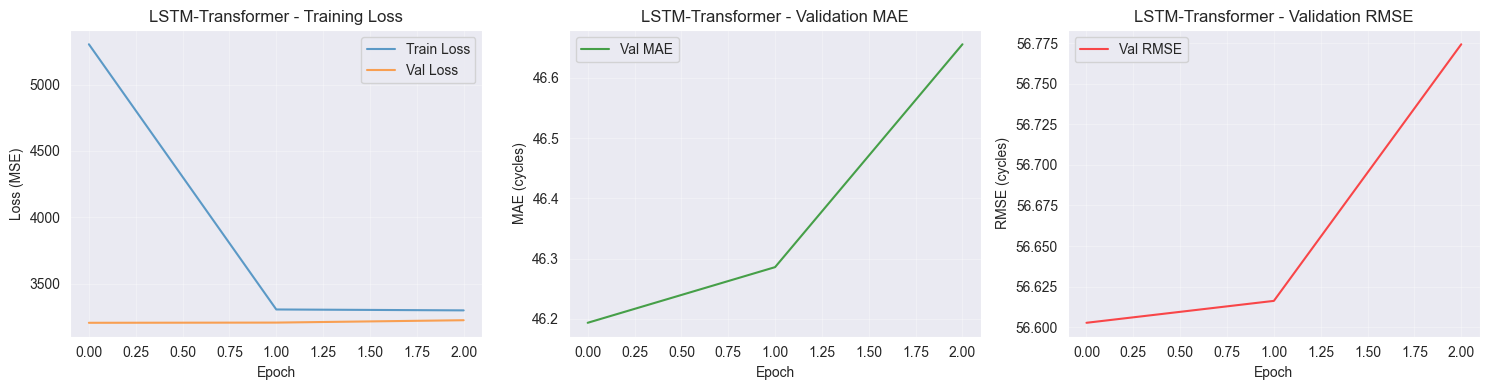

Finished training LSTM-Transformer on Linear RUL (No Norm) (seed=1234)

[2/63] Training GRU-Transformer on Linear RUL (No Norm) with seed 1234...

Training GRU-Transformer on Linear RUL (No Norm)
Data Type: FD001 | SEED: 1234
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5260.251295     3250.571728     46.9994      57.0047     
✅ Model saved: models/seed1234/GRU_Transformer_Linear_RUL_No_Norm_seed1234.pth



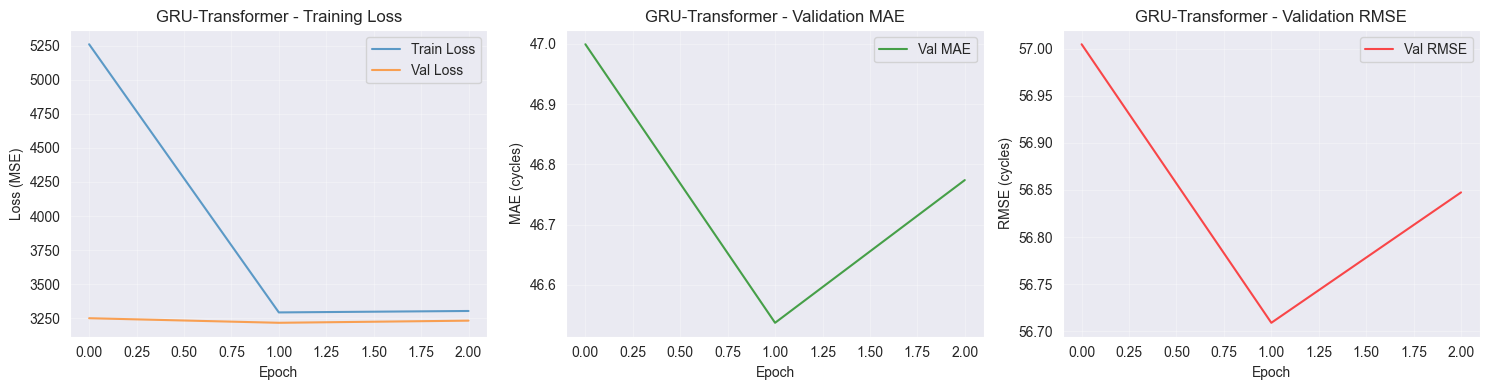

Finished training GRU-Transformer on Linear RUL (No Norm) (seed=1234)

[3/63] Training CNN-Transformer on Linear RUL (No Norm) with seed 1234...

Training CNN-Transformer on Linear RUL (No Norm)
Data Type: FD001 | SEED: 1234
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        4479.019204     9429.198143     79.2642      97.0924     
✅ Model saved: models/seed1234/CNN_Transformer_Linear_RUL_No_Norm_seed1234.pth



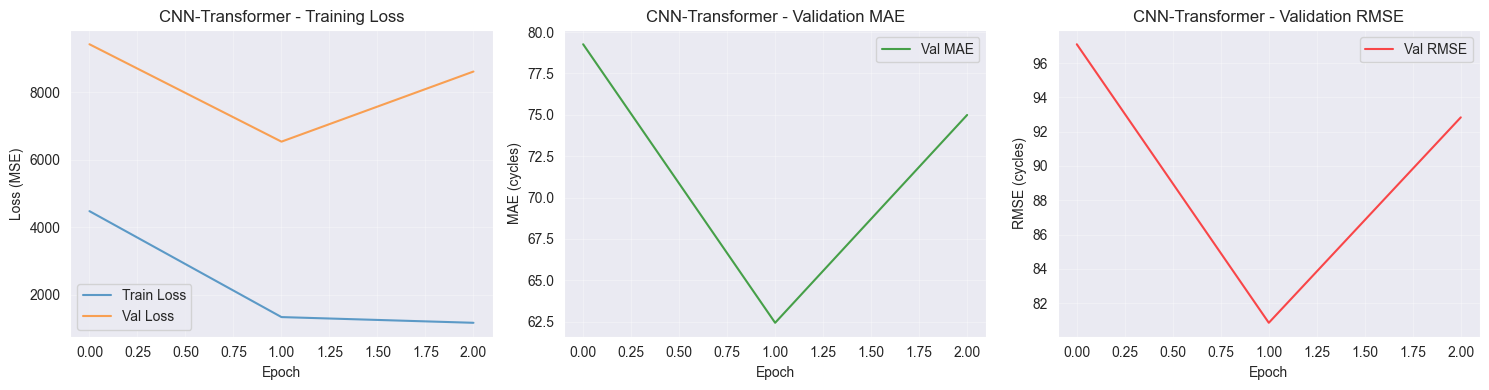

Finished training CNN-Transformer on Linear RUL (No Norm) (seed=1234)


████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
SEED 1234 | DATASET: Linear RUL (Normalized)                                                                            
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

[4/63] Training LSTM-Transformer on Linear RUL (Normalized) with seed 1234...

Training LSTM-Transformer on Linear RUL (Normalized)
Data Type: FD001 | SEED: 1234
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        4393.397057     972.751703      22.2128      31.1321     
✅ Model saved: models/seed1234/LSTM_Transformer_Linear_RUL_Normalized_seed1234.pth



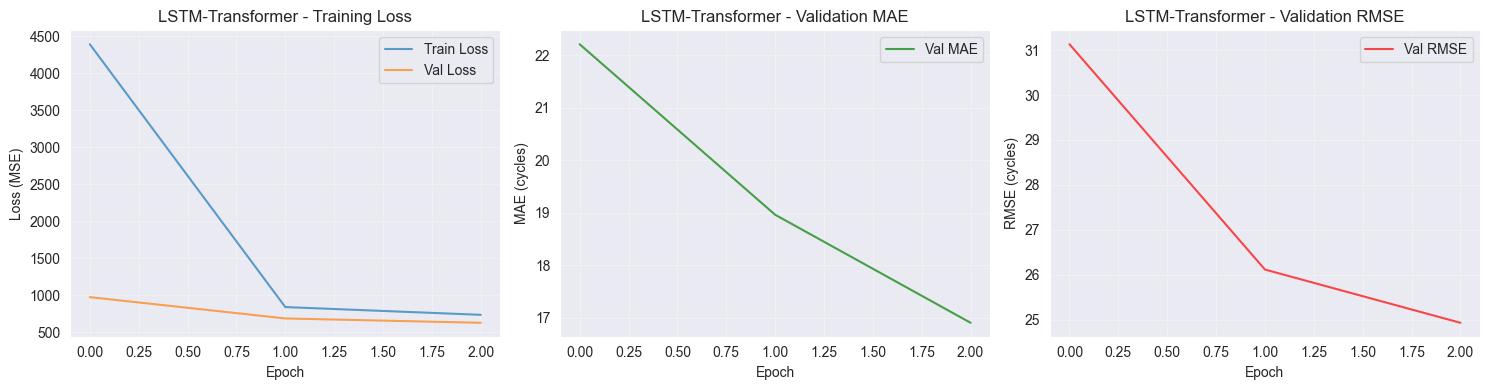

Finished training LSTM-Transformer on Linear RUL (Normalized) (seed=1234)

[5/63] Training GRU-Transformer on Linear RUL (Normalized) with seed 1234...

Training GRU-Transformer on Linear RUL (Normalized)
Data Type: FD001 | SEED: 1234
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        4127.026421     670.410438      16.8633      25.8985     
✅ Model saved: models/seed1234/GRU_Transformer_Linear_RUL_Normalized_seed1234.pth



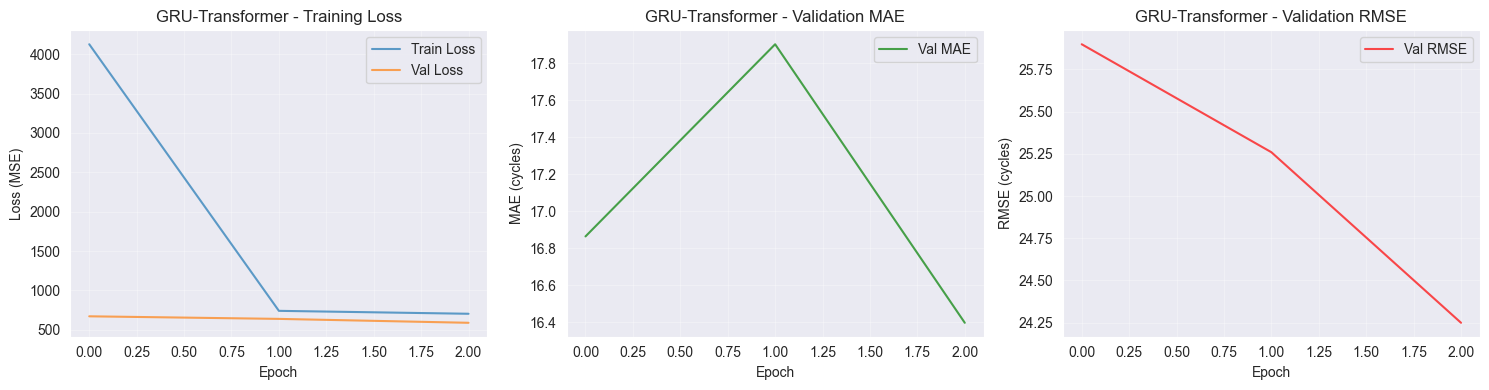

Finished training GRU-Transformer on Linear RUL (Normalized) (seed=1234)

[6/63] Training CNN-Transformer on Linear RUL (Normalized) with seed 1234...

Training CNN-Transformer on Linear RUL (Normalized)
Data Type: FD001 | SEED: 1234
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        3973.852041     691.131905      16.4281      26.2976     
✅ Model saved: models/seed1234/CNN_Transformer_Linear_RUL_Normalized_seed1234.pth



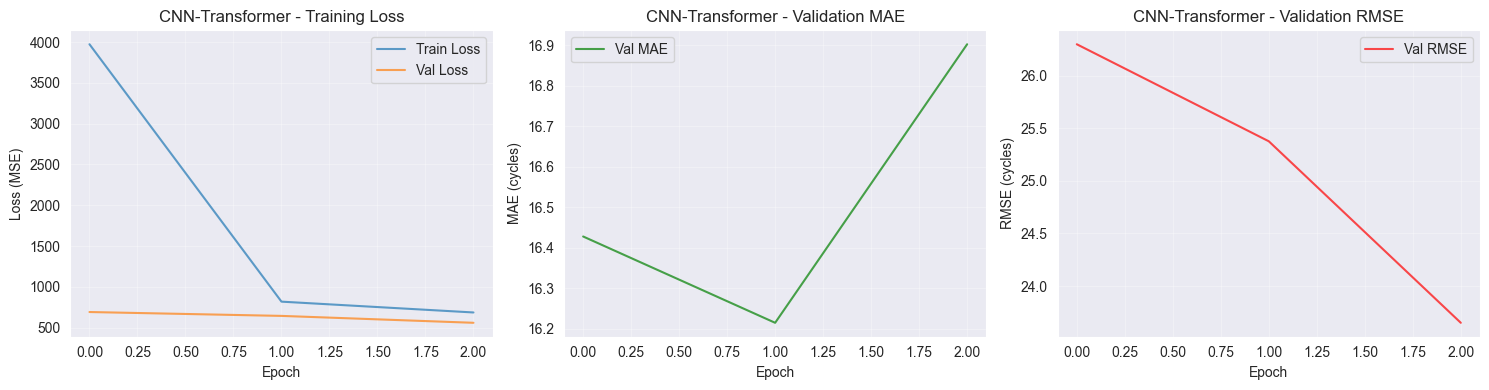

Finished training CNN-Transformer on Linear RUL (Normalized) (seed=1234)


████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
SEED 1234 | DATASET: Piecewise RUL (150)                                                                                
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

[7/63] Training LSTM-Transformer on Piecewise RUL (150) with seed 1234...

Training LSTM-Transformer on Piecewise RUL (150)
Data Type: FD001 | SEED: 1234
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        3193.457908     444.523081      15.8104      20.9144     
✅ Model saved: models/seed1234/LSTM_Transformer_Piecewise_RUL_150_seed1234.pth



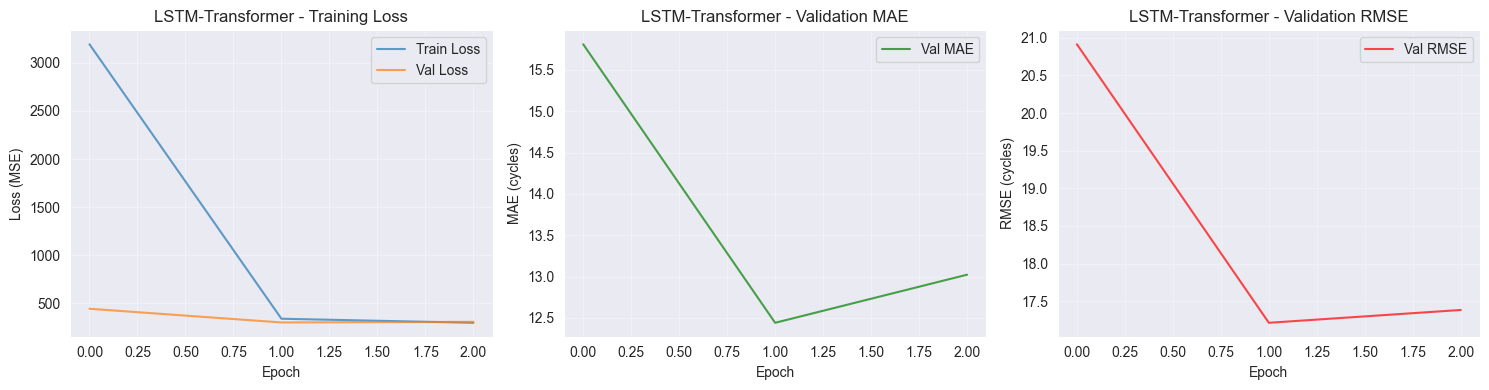

Finished training LSTM-Transformer on Piecewise RUL (150) (seed=1234)

[8/63] Training GRU-Transformer on Piecewise RUL (150) with seed 1234...

Training GRU-Transformer on Piecewise RUL (150)
Data Type: FD001 | SEED: 1234
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        3071.110031     275.631459      12.5858      16.6087     


KeyboardInterrupt: 

In [28]:
# ============ TRAIN ALL 3 MODELS ON ALL 5 DATASETS × 3 SEEDS ============

print("\n" + "="*120)
print("COMPREHENSIVE MULTI-SEED MODEL TRAINING: 3 Models × 7 Datasets × 3 Seeds = 63 Training Runs".center(120))
print("="*120)

# Get dataset names and model names from existing structures
dataset_names = list(datasets_config.keys())
model_names_list = ['LSTM-Transformer', 'GRU-Transformer', 'CNN-Transformer']

# Helper to get feature count for each dataset
get_num_features = lambda dataset_name: len([col for col in datasets_config[dataset_name][0].columns 
                                            if col[0] == 's' and col[1:].isdigit()])

# Model factory functions
models_config_dict = {
    'LSTM-Transformer': lambda nf: LSTMTransformer(num_features=nf, 
                                                lstm_hidden=64, 
                                                num_lstm_layers=2,
                                                d_model=64, 
                                                nhead=4, 
                                                num_transformer_layers=2, 
                                                dropout=0.1),
    'GRU-Transformer': lambda nf: GRUTransformer(num_features=nf, 
                                                gru_hidden=64, 
                                                num_gru_layers=2,
                                                d_model=64,
                                                nhead=4, 
                                                num_transformer_layers=2, 
                                                dropout=0.1),
    'CNN-Transformer': lambda nf: CNNTransformer(num_features=nf, 
                                                num_filters=32, 
                                                kernel_size=3,
                                                d_model=64, 
                                                nhead=4, 
                                                num_transformer_layers=2, 
                                                dropout=0.1)
}


trained_models_all = {}
training_results_all = {}

total_runs = len(SEEDS) * len(dataset_names) * len(model_names_list)
current_run = 0

# Outer loop: iterate through each seed
for seed in SEEDS:
    print(f"\n{'='*120}")
    print(f"SEED: {seed}".center(120))
    print(f"{'='*120}\n")
    
    # Re-seed at the start of each seed iteration
    seed_everything(seed)
    
    # Inner loop: iterate through each dataset
    for dataset_name in dataset_names:
        print(f"\n{'█'*120}")
        print(f"SEED {seed} | DATASET: {dataset_name}".ljust(120))
        print(f"{'█'*120}\n")
        
        # Get loaders for this seed/dataset combination and feature count
        train_loader_current = loaders_by_seed[seed][dataset_name]['train']
        val_loader_current = loaders_by_seed[seed][dataset_name]['val']
        num_features = get_num_features(dataset_name)
        
        # Innermost loop: iterate through each model
        for model_name in model_names_list:
            current_run += 1
            print(f"[{current_run}/{total_runs}] Training {model_name} on {dataset_name} with seed {seed}...")
            
            # Create fresh model instance for this seed/dataset combination
            model = models_config_dict[model_name](num_features)
            trainer = ModelTrainer(model, 
                                    DEVICE, 
                                    f"{model_name}", 
                                    dataset_name=dataset_name, 
                                    models_dir='models', 
                                    logs_dir='logs',
                                    seed=seed,
                                    data_type='FD001')
            history = trainer.train(
                train_loader_current, 
                val_loader_current, 
                epochs=3, 
                lr=0.001, 
                early_stopping_patience=10
            )
            
            # Store results with seed information
            key = (seed, dataset_name, model_name)
            trained_models_all[key] = model
            training_results_all[key] = history

            # Plot training history for this run
            trainer.plot_history()
            print(f"Finished training {model_name} on {dataset_name} (seed={seed})\n")

### Model Management with Seed-Based Organization

**Seed-Based Model Saving:**
- All models are now saved in separate directories based on their SEED value
- Current Seed: **{SEED}** 
- Models saved to: `models/seed{SEED}/`
- Model filename format: `{ModelName}_{DatasetName}_seed{SEED}.pth`

**Available Seeds:**
- `seed1234` - Original seed (default)
- `seed42` - Additional seed variant
- `seed999` - Alternative seed variant

**Benefits:**
- Separates model runs by seed for reproducibility analysis
- Allows comparison of model performance across different random initializations
- Prevents model overwriting when using different seeds
- Easy to track which seed produces the best results

**Loading Models:**
To load a model from a specific seed, specify the `models_dir` and ensure the seed is in the filename.

In [30]:
### Utility function to load models from seed-based directories ###

def load_model_from_seed(model_name, dataset_name, num_features, device, seed, model_type='LSTM-Transformer', models_dir='models'):
    """
    Load a model from a seed-based directory
    
    Args:
        model_name: Base model name (e.g., 'LSTM-Transformer')
        dataset_name: Dataset name used during training
        num_features: Number of input features
        device: Device to load model to
        seed: Random seed used during training
        model_type: Type of model ('LSTM-Transformer', 'GRU-Transformer', or 'CNN-Transformer')
        models_dir: Base models directory (default: 'models')
    
    Returns:
        Loaded model on specified device
    """
    # Clean dataset name
    clean_dataset = dataset_name.replace(' ', '_').replace('(', '').replace(')', '')
    clean_model = model_name.replace('-', '_')
    
    # Construct filename with seed
    model_filename = f"{clean_model}_{clean_dataset}_seed{seed}.pth"
    model_path = os.path.join(models_dir, f'seed{seed}', model_filename)
    
    if not os.path.exists(model_path):
        print(f"❌ Model not found at: {model_path}")
        print(f"   Available seeds: {', '.join([d for d in os.listdir(models_dir) if d.startswith('seed')])}")
        return None
    
    # Create model architecture
    if model_type == 'LSTM-Transformer':
        model = LSTMTransformer(num_features=num_features, lstm_hidden=64, num_lstm_layers=2,
                                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1)
    elif model_type == 'GRU-Transformer':
        model = GRUTransformer(num_features=num_features, gru_hidden=64, num_gru_layers=2,
                                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1)
    elif model_type == 'CNN-Transformer':
        model = CNNTransformer(num_features=num_features, num_filters=32, kernel_size=3,
                                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1)
    else:
        print(f"❌ Unknown model type: {model_type}")
        return None
    
    # Load weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    
    print(f"✅ Model loaded successfully from: {model_path}")
    return model

In [32]:
### Seed-Based Model Organization Verification ###

import os
from pathlib import Path

def verify_seed_model_structure(models_base_dir='models'):
    """Verify and list all seed-based model organization"""
    print("\n" + "="*80)
    print("SEED-BASED MODEL ORGANIZATION VERIFICATION")
    print("="*80)
    
    if not Path(models_base_dir).exists():
        print(f"\n❌ Models directory not found: {models_base_dir}")
        return
    
    # List all seed directories
    seed_dirs = sorted([d for d in os.listdir(models_base_dir) 
                        if os.path.isdir(os.path.join(models_base_dir, d)) and d.startswith('seed')])
    
    print(f"\n✓ Found {len(seed_dirs)} seed directories:\n")
    
    for seed_dir in seed_dirs:
        seed_path = os.path.join(models_base_dir, seed_dir)
        seed_num = seed_dir.replace('seed', '')
        models_in_dir = [f for f in os.listdir(seed_path) if f.endswith('.pth')]
        
        # Check if seed matches current SEED
        current_marker = " ← CURRENT" if int(seed_num) == SEED else ""
        print(f"📁 {seed_dir:<20}{current_marker}")
        print(f"   Location: {seed_path}")
        print(f"   Models: {len(models_in_dir)}")
        
        if len(models_in_dir) > 0:
            print(f"   Files:")
            for model_file in sorted(models_in_dir)[:5]:  # Show first 5
                file_size = os.path.getsize(os.path.join(seed_path, model_file)) / 1024 / 1024  # MB
                print(f"      • {model_file} ({file_size:.2f} MB)")
            if len(models_in_dir) > 5:
                print(f"      ... and {len(models_in_dir) - 5} more models")
        else:
            print(f"   ⚠️  No models saved yet")
        print()

# Run verification
verify_seed_model_structure()


SEED-BASED MODEL ORGANIZATION VERIFICATION

✓ Found 3 seed directories:

📁 seed1234            
   Location: models/seed1234
   Models: 7
   Files:
      • CNN_Transformer_Linear_RUL_No_Norm_seed1234.pth (0.44 MB)
      • CNN_Transformer_Linear_RUL_Normalized_seed1234.pth (0.44 MB)
      • GRU_Transformer_Linear_RUL_No_Norm_seed1234.pth (0.60 MB)
      • GRU_Transformer_Linear_RUL_Normalized_seed1234.pth (0.60 MB)
      • LSTM_Transformer_Linear_RUL_No_Norm_seed1234.pth (0.66 MB)
      ... and 2 more models

📁 seed42               ← CURRENT
   Location: models/seed42
   Models: 1
   Files:
      • LSTM_Transformer_Linear_RUL_No_Norm_seed42.pth (0.66 MB)

📁 seed999             
   Location: models/seed999
   Models: 0
   ⚠️  No models saved yet



In [35]:
# ============ EVALUATE ALL MODELS ON ALL TEST SETS ============

def phm08_scoring_function(y_pred, y_true):
    """
    PHM08 Competition Scoring Function
    Asymmetric cost function: penalizes early predictions more than late ones
    
    Score = sum(exp(-d_i/13) - 1) if d_i < 0 (over-estimate: early prediction)
        = sum(exp(d_i/10) - 1) if d_i >= 0 (under-estimate: late prediction)
    
    where d_i = y_pred_i - y_true_i
    """
    errors = y_pred - y_true
    score = 0
    
    for error in errors:
        if error < 0:  # Over-estimate (predicted fewer cycles remaining)
            score += np.exp(-error / 13) - 1
        else:  # Under-estimate (predicted more cycles remaining)
            score += np.exp(error / 10) - 1
    
    return score

def weighted_rul_error(y_pred, y_true):
    """
    Weighted RUL Error - penalizes late stage failures more
    """
    errors = np.abs(y_pred - y_true)
    weights = 1 + (y_true / y_true.max())  # Higher weight for higher RUL values
    weighted_error = np.mean(errors * weights)
    return weighted_error

def evaluate_model(model, test_loader, device, model_name):
    """Evaluate model on test set and return predictions and metrics"""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            predictions = model(X_batch)
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y_batch.numpy())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)
    weighted_error = weighted_rul_error(all_preds, all_targets)
    phm08_score = phm08_scoring_function(all_preds, all_targets)
    
    return {
        'predictions': all_preds,
        'targets': all_targets,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'weighted_error': weighted_error,
        'phm08_score': phm08_score
    }

def load_model_from_disk(model_name, dataset_name, num_features, device, seed, models_dir='models'):
    """
    Load model from seed-specific directory on disk and return model instance.
    
    Args:
        model_name: Model architecture name (LSTM-Transformer, GRU-Transformer, CNN-Transformer)
        dataset_name: Dataset name (used to find the saved file)
        num_features: Number of input features
        device: Device to load model to
        seed: Random seed used during training
        models_dir: Base directory where seed-specific model folders are saved
    
    Returns:
        model: Loaded model on device, or None if not found
    """
    import os
    from pathlib import Path
    
    # Build seed-specific path and filename
    safe_model_name = model_name.replace('-', '_')
    safe_dataset_name = dataset_name.replace(' ', '_').replace('(', '').replace(')', '')
    model_filename = f"{safe_model_name}_{safe_dataset_name}_seed{seed}.pth"
    seed_dir = os.path.join(models_dir, f'seed{seed}')
    model_path = os.path.join(seed_dir, model_filename)
    
    # Check if file exists
    if not os.path.exists(model_path):
        print(f"      ❌ Model file not found: {model_path}")
        return None
    
    try:
        # Create model instance
        if 'LSTM' in model_name:
            model = LSTMTransformer(
                num_features=num_features,
                lstm_hidden=64,
                num_lstm_layers=2,
                d_model=64,
                nhead=4,
                num_transformer_layers=2,
                dropout=0.1
            )
        elif 'GRU' in model_name:
            model = GRUTransformer(
                num_features=num_features,
                gru_hidden=64,
                num_gru_layers=2,
                d_model=64,
                nhead=4,
                num_transformer_layers=2,
                dropout=0.1
            )
        elif 'CNN' in model_name:
            model = CNNTransformer(
                num_features=num_features,
                num_filters=32,
                kernel_size=3,
                d_model=64,
                nhead=4,
                num_transformer_layers=2,
                dropout=0.1
            )
        else:
            print(f"      ❌ Unknown model type: {model_name}")
            return None
        
        # Load weights from disk
        model.load_state_dict(torch.load(model_path, map_location=device))
        model = model.to(device)
        model.eval()
        
        print(f"      ✅ Loaded: {model_filename}")
        return model
    
    except Exception as e:
        print(f"      ❌ Error loading model: {e}")
        return None

# ============ EVALUATE ALL MODELS ON ALL TEST SETS (LOAD FROM SEED-SPECIFIC DIRECTORIES) ============

print("\n" + "="*140)
print("MULTI-SEED EVALUATION: LOADING MODELS & EVALUATING ON SEED-SPECIFIC TEST SETS".center(140))
print("="*140)

test_results_all = {}

# Outer loop: iterate through each seed
for seed in SEEDS:
    print(f"\n{'='*140}")
    print(f"SEED: {seed}".center(140))
    print(f"{'='*140}")
    
    # Middle loop: iterate through each dataset
    for dataset_name in dataset_names:
        print(f"\n  📂 Dataset: {dataset_name}")
        test_loader_current = loaders_by_seed[seed][dataset_name]['test']
        num_features = get_num_features(dataset_name)
        
        # Inner loop: iterate through each model
        for model_name in model_names_list:
            key = (seed, dataset_name, model_name)
            
            # Load model from seed-specific directory
            model = load_model_from_disk(model_name, dataset_name, num_features, DEVICE, seed, models_dir='models')
            
            if model is None:
                print(f"    ⚠️  Skipping {model_name} - model file not found")
                continue
            
            # Evaluate model with seed-specific test data
            results = evaluate_model(model, test_loader_current, DEVICE, f"{model_name} on {dataset_name} (seed={seed})")
            test_results_all[key] = results

# ============ COMPILE RESULTS IN MULTI-SEED TABLE FORMAT ============

print("\n" + "="*140)
print("RESULTS SUMMARY: All Models × All Datasets × All Seeds".center(140))
print("="*140)

# Compile results into a detailed DataFrame including seeds
results_data = []
for seed in SEEDS:
    for dataset_name in dataset_names:
        for model_name in model_names_list:
            key = (seed, dataset_name, model_name)
            
            # Skip if results don't exist (model wasn't evaluated)
            if key not in test_results_all:
                continue
            
            results = test_results_all[key]
            
            results_data.append({
                'Seed': seed,
                'Dataset': dataset_name,
                'Model': model_name,
                'MAE': f"{results['mae']:.4f}",
                'RMSE': f"{results['rmse']:.4f}",
                'R²': f"{results['r2']:.4f}",
                'PHM08': f"{results['phm08_score']:.2f}"
            })

results_df = pd.DataFrame(results_data)
print("\n" + results_df.to_string(index=False))
print("\n" + "="*140)

# Find best model for each dataset × seed combination
print("\nBEST MODELS BY DATASET × SEED (Lowest RMSE):\n")
for seed in SEEDS:
    print(f"  SEED {seed}:")
    for dataset_name in dataset_names:
        best_model = None
        best_rmse = float('inf')
        
        for model_name in model_names_list:
            key = (seed, dataset_name, model_name)
            
            # Skip if model wasn't evaluated
            if key not in test_results_all:
                continue
            
            rmse = test_results_all[key]['rmse']
            if rmse < best_rmse:
                best_rmse = rmse
                best_model = model_name
        
        if best_model:
            print(f"    {dataset_name:<25} → {best_model:<20} (RMSE: {best_rmse:.4f})")
        else:
            print(f"    {dataset_name:<25} → No models evaluated")
    print()

# Overall best model across all seed + dataset combinations
print("OVERALL BEST MODELS (Avg RMSE across all datasets for each seed):\n")
for seed in SEEDS:
    model_avg_rmse = {}
    for model_name in model_names_list:
        rmse_list = []
        for dataset_name in dataset_names:
            key = (seed, dataset_name, model_name)
            
            # Skip if model wasn't evaluated
            if key not in test_results_all:
                continue
            
            rmse_list.append(test_results_all[key]['rmse'])
        
        # Only add to average if at least one evaluation exists
        if rmse_list:
            model_avg_rmse[model_name] = np.mean(rmse_list)
    
    if model_avg_rmse:
        print(f"  Seed {seed}:")
        best_overall = min(model_avg_rmse, key=model_avg_rmse.get)
        for model_name, avg_rmse in sorted(model_avg_rmse.items(), key=lambda x: x[1]):
            print(f"    {model_name:<20} - Avg RMSE: {avg_rmse:.4f}")
        print(f"    ⭐ Winner: {best_overall}\n")
    else:
        print(f"  Seed {seed}: No models evaluated successfully.\n")

print("="*140)


                               MULTI-SEED EVALUATION: LOADING MODELS & EVALUATING ON SEED-SPECIFIC TEST SETS                                

                                                                 SEED: 1234                                                                 

  📂 Dataset: Linear RUL (No Norm)
      ✅ Loaded: LSTM_Transformer_Linear_RUL_No_Norm_seed1234.pth
      ✅ Loaded: GRU_Transformer_Linear_RUL_No_Norm_seed1234.pth
      ✅ Loaded: CNN_Transformer_Linear_RUL_No_Norm_seed1234.pth

  📂 Dataset: Linear RUL (Normalized)
      ✅ Loaded: LSTM_Transformer_Linear_RUL_Normalized_seed1234.pth
      ✅ Loaded: GRU_Transformer_Linear_RUL_Normalized_seed1234.pth
      ✅ Loaded: CNN_Transformer_Linear_RUL_Normalized_seed1234.pth

  📂 Dataset: Piecewise RUL (150)
      ✅ Loaded: LSTM_Transformer_Piecewise_RUL_150_seed1234.pth
      ❌ Model file not found: models/seed1234/GRU_Transformer_Piecewise_RUL_150_seed1234.pth
    ⚠️  Skipping GRU-Transformer - model file not found
 

In [36]:
# ============ COMPILE RESULTS IN MULTI-SEED TABLE FORMAT ============

print("\n" + "="*140)
print("RESULTS SUMMARY: All Models × All Datasets × All Seeds".center(140))
print("="*140)

# Compile results into a detailed DataFrame including seeds
results_data = []
for seed in SEEDS:
    for dataset_name in dataset_names:
        for model_name in model_names_list:
            key = (seed, dataset_name, model_name)
            
            # Skip if results don't exist (model wasn't evaluated)
            if key not in test_results_all:
                continue
            
            results = test_results_all[key]
            
            results_data.append({
                'Seed': seed,
                'Dataset': dataset_name,
                'Model': model_name,
                'MAE': f"{results['mae']:.4f}",
                'RMSE': f"{results['rmse']:.4f}",
                'R²': f"{results['r2']:.4f}",
                'PHM08': f"{results['phm08_score']:.2f}"
            })

results_df = pd.DataFrame(results_data)
print("\n" + results_df.to_string(index=False))
print("\n" + "="*140)

# Find best model for each dataset × seed combination
print("\nBEST MODELS BY DATASET × SEED (Lowest RMSE):\n")
for seed in SEEDS:
    print(f"  SEED {seed}:")
    for dataset_name in dataset_names:
        best_model = None
        best_rmse = float('inf')
        
        for model_name in model_names_list:
            key = (seed, dataset_name, model_name)
            
            # Skip if model wasn't evaluated
            if key not in test_results_all:
                continue
            
            rmse = test_results_all[key]['rmse']
            if rmse < best_rmse:
                best_rmse = rmse
                best_model = model_name
        
        if best_model:
            print(f"    {dataset_name:<25} → {best_model:<20} (RMSE: {best_rmse:.4f})")
        else:
            print(f"    {dataset_name:<25} → No models evaluated")
    print()

# Overall best model across all seed + dataset combinations
print("OVERALL BEST MODELS (Avg RMSE across all datasets for each seed):\n")
for seed in SEEDS:
    model_avg_rmse = {}
    for model_name in model_names_list:
        rmse_list = []
        for dataset_name in dataset_names:
            key = (seed, dataset_name, model_name)
            
            # Skip if model wasn't evaluated
            if key not in test_results_all:
                continue
            
            rmse_list.append(test_results_all[key]['rmse'])
        
        # Only add to average if at least one evaluation exists
        if rmse_list:
            model_avg_rmse[model_name] = np.mean(rmse_list)
    
    if model_avg_rmse:
        print(f"  Seed {seed}:")
        best_overall = min(model_avg_rmse, key=model_avg_rmse.get)
        for model_name, avg_rmse in sorted(model_avg_rmse.items(), key=lambda x: x[1]):
            print(f"    {model_name:<20} - Avg RMSE: {avg_rmse:.4f}")
        print(f"    ⭐ Winner: {best_overall}\n")
    else:
        print(f"  Seed {seed}: No models evaluated successfully.\n")

print("="*140)


                                           RESULTS SUMMARY: All Models × All Datasets × All Seeds                                           

 Seed                 Dataset            Model      MAE     RMSE      R²          PHM08
 1234    Linear RUL (No Norm) LSTM-Transformer  47.4733  59.8783 -0.3211   151033104.00
 1234    Linear RUL (No Norm)  GRU-Transformer  47.1254  59.4616 -0.3028   141467728.00
 1234    Linear RUL (No Norm)  CNN-Transformer 107.4690 119.0120 -4.2190 52495716352.00
 1234 Linear RUL (Normalized) LSTM-Transformer  22.7383  32.1419  0.6193     3126582.00
 1234 Linear RUL (Normalized)  GRU-Transformer  22.6336  31.3744  0.6373     2079705.88
 1234 Linear RUL (Normalized)  CNN-Transformer  28.0891  36.4319  0.5109     2434739.25
 1234     Piecewise RUL (150) LSTM-Transformer  14.8778  18.6574  0.7716       78930.48
   42    Linear RUL (No Norm) LSTM-Transformer  49.1613  61.8812 -0.4110   203239568.00


BEST MODELS BY DATASET × SEED (Lowest RMSE):

  SEED 1234:
    

In [37]:
# ============ VISUALIZATION: MINIMAL COMPARISON PLOTS (WITH FAILSAFE) ============

def build_evaluation_data(test_results_all, dataset_names, model_names_list):
    """
    Safely build evaluation data, only including models that were successfully evaluated.
    Returns available datasets and models, plus their metrics.
    """
    # Find available models and datasets from actual results
    available_models = set()
    available_datasets = set()
    
    for (dataset_name, model_name) in test_results_all.keys():
        available_models.add(model_name)
        available_datasets.add(dataset_name)
    
    # Filter to use only available combinations
    available_models = [m for m in model_names_list if m in available_models]
    available_datasets = [d for d in dataset_names if d in available_datasets]
    
    if not available_models or not available_datasets:
        print("⚠️  No successful model evaluations found!")
        return None
    
    print(f"✅ Found {len(available_models)} available models and {len(available_datasets)} available datasets")
    print(f"   Models: {', '.join(available_models)}")
    print(f"   Datasets: {', '.join(available_datasets)}")
    
    # Build metrics dictionaries only for available combinations
    rmse_by_model_dataset = {}
    r2_by_model_dataset = {}
    
    for model_name in available_models:
        rmse_by_model_dataset[model_name] = []
        r2_by_model_dataset[model_name] = []
        
        for dataset_name in available_datasets:
            key = (dataset_name, model_name)
            
            # Only add if this combination exists
            if key in test_results_all:
                rmse_by_model_dataset[model_name].append(test_results_all[key]['rmse'])
                r2_by_model_dataset[model_name].append(test_results_all[key]['r2'])
            else:
                # Skip missing combinations (will be shown as gaps)
                pass
    
    return {
        'rmse_by_model_dataset': rmse_by_model_dataset,
        'r2_by_model_dataset': r2_by_model_dataset,
        'available_models': available_models,
        'available_datasets': available_datasets
    }

# ============ BUILD AND VALIDATE EVALUATION DATA ============

eval_data = build_evaluation_data(test_results_all, dataset_names, model_names_list)

if eval_data is None:
    print("\n❌ Cannot create visualization - no successful model evaluations")
else:
    # Extract data
    rmse_by_model_dataset = eval_data['rmse_by_model_dataset']
    r2_by_model_dataset = eval_data['r2_by_model_dataset']
    available_models = eval_data['available_models']
    available_datasets = eval_data['available_datasets']
    
    # Create compact 2x2 comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Model Performance Comparison (Available Models Only)', fontsize=14, fontweight='bold')
    
    # 1. RMSE comparison - grouped by model
    x = np.arange(len(available_datasets))
    width = 0.25 if len(available_models) > 1 else 0.4
    
    for idx, model_name in enumerate(available_models):
        axes[0, 0].bar(x + idx*width, rmse_by_model_dataset[model_name], width, label=model_name, alpha=0.8)
    
    axes[0, 0].set_xlabel('Dataset')
    axes[0, 0].set_ylabel('RMSE (cycles)')
    axes[0, 0].set_title('RMSE Comparison by Dataset')
    axes[0, 0].set_xticks(x + width * (len(available_models) - 1) / 2)
    axes[0, 0].set_xticklabels([d.replace(' ', '\n') for d in available_datasets], fontsize=9)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 2. R² comparison - grouped by model
    for idx, model_name in enumerate(available_models):
        axes[0, 1].bar(x + idx*width, r2_by_model_dataset[model_name], width, label=model_name, alpha=0.8)
    
    axes[0, 1].set_xlabel('Dataset')
    axes[0, 1].set_ylabel('R² Score')
    axes[0, 1].set_title('R² Comparison by Dataset')
    axes[0, 1].set_xticks(x + width * (len(available_models) - 1) / 2)
    axes[0, 1].set_xticklabels([d.replace(' ', '\n') for d in available_datasets], fontsize=9)
    axes[0, 1].set_ylim([-1, 1])
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. RMSE heatmap
    rmse_matrix = np.array([[rmse_by_model_dataset[m][i] for m in available_models] for i in range(len(available_datasets))])
    im = axes[1, 0].imshow(rmse_matrix, cmap='RdYlGn_r', aspect='auto')
    axes[1, 0].set_xticks(np.arange(len(available_models)))
    axes[1, 0].set_yticks(np.arange(len(available_datasets)))
    axes[1, 0].set_xticklabels(available_models, rotation=45, ha='right')
    axes[1, 0].set_yticklabels(available_datasets, fontsize=9)
    axes[1, 0].set_title('RMSE Heatmap (Lower=Better)')
    
    # Add values to heatmap
    for i in range(len(available_datasets)):
        for j in range(len(available_models)):
            text = axes[1, 0].text(j, i, f'{rmse_matrix[i, j]:.3f}',
                                    ha="center", va="center", color="black", fontsize=8)
    
    plt.colorbar(im, ax=axes[1, 0], label='RMSE (cycles)')
    
    # 4. Model performance ranking
    model_avg_rmse = {}
    for model_name in available_models:
        rmse_list = [test_results_all[(dataset_name, model_name)]['rmse'] 
                     for dataset_name in available_datasets 
                     if (dataset_name, model_name) in test_results_all]
        
        if rmse_list:  # Only include if has results
            model_avg_rmse[model_name] = np.mean(rmse_list)
    
    if model_avg_rmse:
        sorted_models = sorted(model_avg_rmse.items(), key=lambda x: x[1])
        model_names_sorted = [m[0] for m in sorted_models]
        rmse_sorted = [m[1] for m in sorted_models]
        colors_rank = ['#2ecc71', '#3498db', '#e74c3c'][:len(sorted_models)]
        
        axes[1, 1].barh(model_names_sorted, rmse_sorted, color=colors_rank, alpha=0.8)
        axes[1, 1].set_xlabel('Average RMSE (cycles)')
        axes[1, 1].set_title('Model Ranking (Lower RMSE = Better)')
        axes[1, 1].grid(True, alpha=0.3, axis='x')
        
        for i, v in enumerate(rmse_sorted):
            axes[1, 1].text(v + 0.1, i, f'{v:.4f}', va='center', fontsize=9)
    else:
        axes[1, 1].text(0.5, 0.5, 'No ranking data available', ha='center', va='center')
        axes[1, 1].set_title('Model Ranking')
    
    plt.tight_layout()
    plt.show()
    

ValueError: too many values to unpack (expected 2)

# FD002 Dataset Exploration & Training

### FD002 has More Complex Operating Conditions (6 different condition combinations)

**Comparison:**
- **FD001:** 3 operating conditions (simpler degradation pattern)
- **FD002:** 6 operating conditions (more complex degradation pattern)


## Part 1: Dataset Exploration for FD002

In [ ]:
### Load FD002 datasets (optional additional dataset) ###

# FD002 - Linear RUL with normalization
train_df_fd002_rul = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_1/train_processed_rul_only_fd002.csv')
test_df_fd002_rul = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_1/test_processed_rul_only_fd002.csv')

# FD002 - Linear RUL without normalization
train_df_fd002_nonorm = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_no_norm_0/train_processed_rul_only_fd002.csv')
test_df_fd002_nonorm = pd.read_csv('../data/processed-nasa-data/data_cleaning_1/linear_rul_no_norm_0/test_processed_rul_only_fd002.csv')

# FD002 - Low Variance feature engineering
train_df_fd002_fe_lowvar = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/low_variance_1/train_fd002_low_variance_1.csv')
test_df_fd002_fe_lowvar = pd.read_csv('../data/processed-nasa-data/feature_engineering_2/low_variance_1/test_fd002_low_variance_1.csv')

print("\n✓ FD002 datasets loaded successfully")
print(f"  - FD002 RUL (Normalized): train={train_df_fd002_rul.shape}, test={test_df_fd002_rul.shape}")
print(f"  - FD002 RUL (No Norm): train={train_df_fd002_nonorm.shape}, test={test_df_fd002_nonorm.shape}")
print(f"  - FD002 Low Variance: train={train_df_fd002_fe_lowvar.shape}, test={test_df_fd002_fe_lowvar.shape}")

In [ ]:
# train_df_fd002 = pd.read_csv('../data/processed-nasa-data/train_processed_rul_only_fd002.csv')
# test_df_fd002 = pd.read_csv('../data/processed-nasa-data/test_processed_rul_only_fd002.csv')

# Google Drive (if running in Colab)
DATA_PATH = '/content/drive/My Drive/deep_learning/project/'
train_df_fd002 = pd.read_csv(f'{DATA_PATH}train_processed_rul_only_fd002.csv')
test_df_fd002 = pd.read_csv(f'{DATA_PATH}test_processed_rul_only_fd002.csv')

print("\n" + "="*100)
print("DATASET COMPARISON: FD001 vs FD002")
print("="*100)

comparison_df_datasets = pd.DataFrame({
    'Metric': ['Training Rows', 'Test Rows', 'Total Rows', 'Train Engines', 'Test Engines', 
               'Train RUL Min', 'Train RUL Max', 'Train RUL Mean', 'Num Sensors', 'Operating Conditions'],
    'FD001': [
        f"{train_df.shape[0]:,}",
        f"{test_df.shape[0]:,}",
        f"{train_df.shape[0] + test_df.shape[0]:,}",
        f"{train_df['id'].nunique()}",
        f"{test_df['id'].nunique()}",
        f"{train_df['RUL'].min()}",
        f"{train_df['RUL'].max()}",
        f"{train_df['RUL'].mean():.2f}",
        f"{len([c for c in train_df.columns if c.startswith('s')])}",
        "3 conditions (simple)"
    ],
    'FD002': [
        f"{train_df_fd002.shape[0]:,}",
        f"{test_df_fd002.shape[0]:,}",
        f"{train_df_fd002.shape[0] + test_df_fd002.shape[0]:,}",
        f"{train_df_fd002['id'].nunique()}",
        f"{test_df_fd002['id'].nunique()}",
        f"{train_df_fd002['RUL'].min()}",
        f"{train_df_fd002['RUL'].max()}",
        f"{train_df_fd002['RUL'].mean():.2f}",
        f"{len([c for c in train_df_fd002.columns if c.startswith('s')])}",
        "6 conditions (complex)"
    ]
})

print("\n" + comparison_df_datasets.to_string(index=False))
print("="*100)

print("\nFD002 EDA - Detailed Analysis:")
print(f"\n  Training: {train_df_fd002.shape[0]:,} rows × {train_df_fd002.shape[1]} columns")
print(f"  Test:     {test_df_fd002.shape[0]:,} rows × {test_df_fd002.shape[1]} columns")
print(f"  Engines:  Train={train_df_fd002['id'].nunique()}, Test={test_df_fd002['id'].nunique()}")
print(f"  RUL Range: Train [{train_df_fd002['RUL'].min()}, {train_df_fd002['RUL'].max()}], Std={train_df_fd002['RUL'].std():.2f}")
print(f"  RUL Range: Test [{test_df_fd002['RUL'].min()}, {test_df_fd002['RUL'].max()}], Std={test_df_fd002['RUL'].std():.2f}")

train_cycles_fd002 = train_df_fd002.groupby('id')['cycle'].max()
test_cycles_fd002 = test_df_fd002.groupby('id')['cycle'].max()
print(f"  Cycles per engine: Train [{train_cycles_fd002.min()}, {train_cycles_fd002.max()}], Avg={train_cycles_fd002.mean():.1f}")
print(f"  Cycles per engine: Test [{test_cycles_fd002.min()}, {test_cycles_fd002.max()}], Avg={test_cycles_fd002.mean():.1f}")



DATASET COMPARISON: FD001 vs FD002

              Metric                 FD001                  FD002
       Training Rows                20,631                 53,759
           Test Rows                13,096                 33,991
          Total Rows                33,727                 87,750
       Train Engines                   100                    260
        Test Engines                   100                    259
       Train RUL Min                     0                      0
       Train RUL Max                   361                    377
      Train RUL Mean                107.81                 108.15
         Num Sensors                    24                     24
Operating Conditions 3 conditions (simple) 6 conditions (complex)

FD002 EDA - Detailed Analysis:

  Training: 53,759 rows × 28 columns
  Test:     33,991 rows × 28 columns
  Engines:  Train=260, Test=259
  RUL Range: Train [0, 377], Std=69.18
  RUL Range: Test [6, 377], Std=63.87
  Cycles per engine: 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RUL Distribution
''' 
- The RUL distribution in the training set is right-skewed, with most samples having a high RUL (indicating healthy engines) and fewer samples with low RUL (indicating engines close to failure).
- The test set has a similar distribution but with a slightly higher mean RUL, suggesting that the test engines may be generally healthier than those in the training set.
'''
axes[0, 0].hist(train_df_fd002['RUL'], bins=50, alpha=0.7, color='blue', label='Train')
axes[0, 0].hist(test_df_fd002['RUL'], bins=50, alpha=0.7, color='orange', label='Test')
axes[0, 0].set_xlabel('RUL (cycles)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('RUL Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Cycles per Engine
''' 
- The number of cycles per engine varies, with some engines running for over 200 cycles before failure.
- The distribution of cycles per engine is right-skewed, with many engines failing after fewer cycles and a long tail of engines that run for many cycles before failure.
'''
train_cycles_dist = train_df_fd002.groupby('id')['cycle'].max()
axes[0, 1].hist(train_cycles_dist, bins=20, color='green', alpha=0.7)
axes[0, 1].set_xlabel('Cycles per Engine')
axes[0, 1].set_ylabel('Number of Engines')
axes[0, 1].set_title('Training: Cycles per Engine Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sample sensor trends (Engine 1)
''' 
- The sensor values for Engine 1 show varying patterns over time, with some sensors exhibiting more noise than others.
- There are noticeable trends in the sensor data that may be indicative of engine degradation. For example, sensor s1 shows a gradual increase in values as the engine approaches failure, while sensor s10 exhibits more erratic behavior.
'''
engine1_data = train_df_fd002[train_df_fd002['id'] == 1].sort_values('cycle')
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s1'], label='s1', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s2'], label='s2', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s3'], label='s3', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s10'], label='s10', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s15'], label='s15', alpha=0.7)
axes[1, 0].set_xlabel('Cycle')
axes[1, 0].set_ylabel('Normalized Sensor Value')
axes[1, 0].set_title('Engine 1: Sample Sensor Trends (s1, s2, s3, s10, s15)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. RUL Decay Pattern (Engine 1)
axes[1, 1].plot(engine1_data['cycle'], engine1_data['RUL'], color='red', linewidth=2)
axes[1, 1].set_xlabel('Cycle')
axes[1, 1].set_ylabel('RUL (cycles)')
axes[1, 1].set_title('Engine 1: RUL Over Time (Monotonically Decreasing)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Data Preparation & Sequence Creation for FD002

In [ ]:
train_dataset_fd002 = RULDataset(train_df_fd002, SEQUENCE_LENGTH, feature_cols)
test_dataset_fd002 = RULDataset(test_df_fd002, SEQUENCE_LENGTH, feature_cols)

train_size_fd002 = int(TRAIN_TEST_SPLIT * len(train_dataset_fd002))
val_size_fd002 = len(train_dataset_fd002) - train_size_fd002
train_dataset_fd002_split, val_dataset_fd002 = random_split(
    train_dataset_fd002,
    [train_size_fd002, val_size_fd002],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader_fd002 = DataLoader(train_dataset_fd002_split, 
                                batch_size=BATCH_SIZE, 
                                shuffle=True, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
val_loader_fd002 = DataLoader(val_dataset_fd002, 
                                batch_size=BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
test_loader_fd002 = DataLoader(test_dataset_fd002, 
                                batch_size=BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)

print(f"  Training sequences: {len(train_dataset_fd002_split):,}")
print(f"  Validation sequences: {len(val_dataset_fd002):,}")
print(f"  Test sequences: {len(test_dataset_fd002):,}")
print(f"  Total: {len(train_dataset_fd002_split) + len(val_dataset_fd002) + len(test_dataset_fd002):,}")
print(f"\n  FD001 Total Sequences: {len(train_dataset) + len(val_dataset) + len(test_dataset):,}")
print(f"  FD002 Total Sequences: {len(train_dataset_fd002_split) + len(val_dataset_fd002) + len(test_dataset_fd002):,}")


FD002: DATA PREPARATION FOR TRAINING

✅ FD002 Datasets Created:
  Training sequences: 36,767
  Validation sequences: 9,192
  Test sequences: 26,252
  Total: 72,211

  FD001 Total Sequences: 27,727
  FD002 Total Sequences: 72,211



## Part 3: Model Training & Evaluation for FD002


TRAINING ALL THREE MODELS ON FD002 DATASET (More Complex)


****************************************************************************************************
Training: LSTM-Transformer on FD002 (Complex Dataset)
****************************************************************************************************

Training LSTM-Transformer (FD002)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5087.442251     3870.027017     51.0063      62.2351     
5        3885.523681     3880.659774     51.2042      62.3203     
10       3853.079741     3884.131713     51.2534      62.3481     
15       3895.103979     3876.662960     51.1402      62.2883     

⏹️  Early stopping at epoch 19



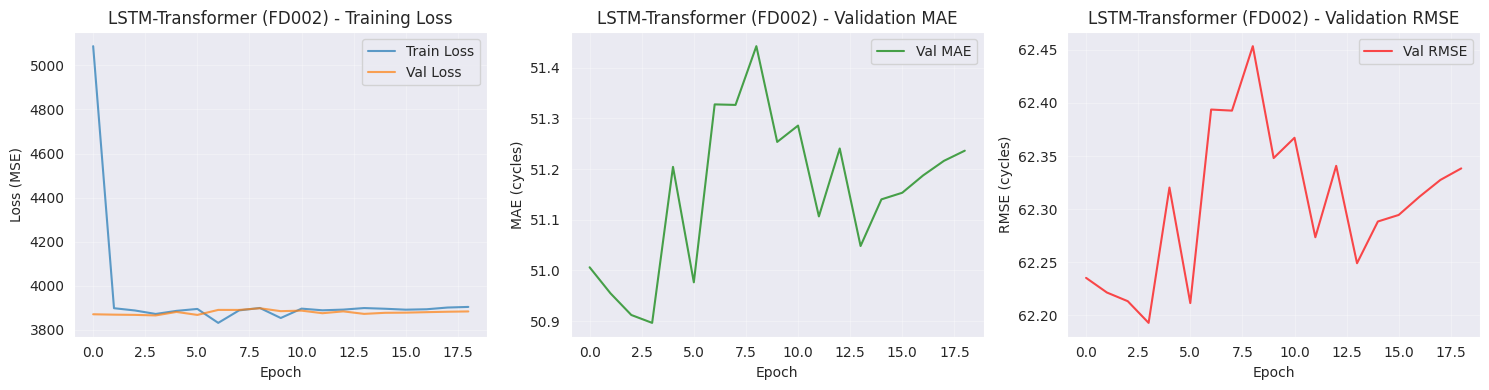


****************************************************************************************************
Training: GRU-Transformer on FD002 (Complex Dataset)
****************************************************************************************************

Training GRU-Transformer (FD002)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        5875.747949     3866.951614     50.8706      62.2106     
5        3972.798933     3876.933394     51.1571      62.2904     
10       3972.074321     3867.075382     50.8686      62.2116     
15       3978.925328     3867.271202     50.8375      62.2132     
20       3975.705354     3869.372093     50.9896      62.2299     

⏹️  Early stopping at epoch 21



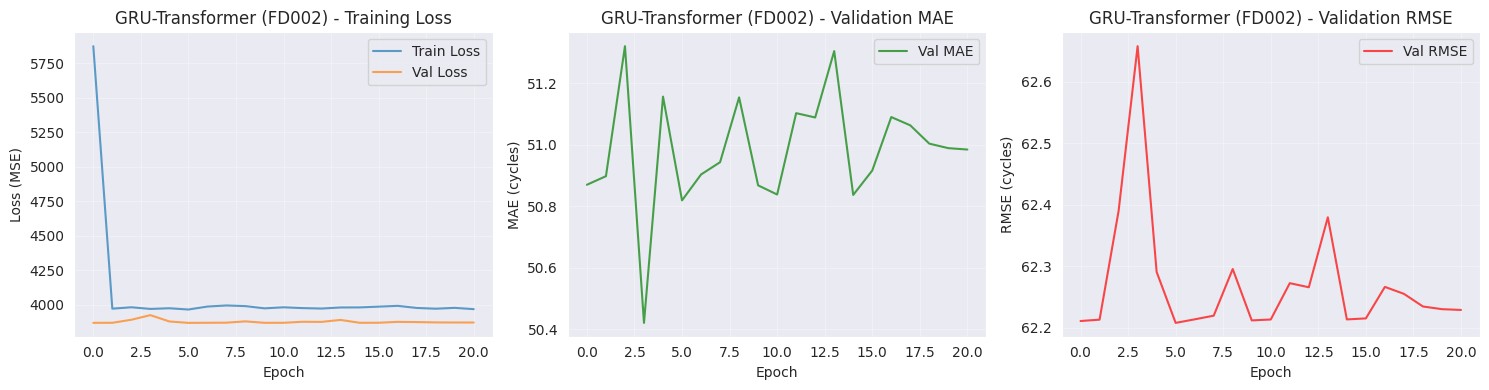


****************************************************************************************************
Training: CNN-Transformer on FD002 (Complex Dataset)
****************************************************************************************************

Training CNN-Transformer (FD002)
Epoch    Train Loss      Val Loss        Val MAE      Val RMSE    
--------------------------------------------------------------------------------
1        3770.495570     1606.819053     30.4028      40.1071     
5        1099.324996     1181.880786     25.0615      34.3976     
10       527.302798      515.970680      16.6329      22.7194     
15       353.417141      229.108520      11.3785      15.1394     
20       287.288446      156.233819      9.3933       12.5086     
25       257.276058      153.318898      9.3703       12.3906     
30       224.676392      130.402047      8.3404       11.4294     
35       206.122918      155.352247      9.6146       12.4742     
40       191.927616      1

In [ ]:
print("\n" + "="*100)
print("TRAINING ALL THREE MODELS ON FD002 DATASET (More Complex)")
print("="*100 + "\n")

models_config_fd002 = {
    'LSTM-Transformer': LSTMTransformer(
        num_features=num_features, 
        lstm_hidden=64, 
        num_lstm_layers=2,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    ),
    'GRU-Transformer': GRUTransformer(
        num_features=num_features, 
        gru_hidden=64, 
        num_gru_layers=2,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    ),
    'CNN-Transformer': CNNTransformer(
        num_features=num_features, 
        num_filters=32, 
        kernel_size=3,
        d_model=64, 
        nhead=4, 
        num_transformer_layers=2, 
        dropout=0.1
    )
}

# Train on FD002 with adjusted settings for complex dataset
trained_models_fd002 = {}
training_results_fd002 = {}

for model_name, model in models_config_fd002.items():
    print(f"\n{'*'*100}")
    print(f"Training: {model_name} on FD002 (Complex Dataset)")
    print(f"{'*'*100}")
    
    trainer = ModelTrainer(model, DEVICE, f"{model_name}", dataset_name='FD002',
                           models_dir=f'models/seed{SEED}', logs_dir='logs',
                           seed=SEED, data_type='FD002')
    # Use lower learning rate and more patience for complex dataset
    history = trainer.train(
        train_loader_fd002, 
        val_loader_fd002, 
        epochs=100,  # More epochs for complex data
        lr=0.0005,   # Lower learning rate for stable convergence
        early_stopping_patience=15  # More patience
    )
    
    trained_models_fd002[model_name] = model
    training_results_fd002[model_name] = history

In [ ]:
print("\n" + "="*100)
print("EVALUATING FD002 MODELS ON TEST SET")
print("="*100)

test_results_fd002 = {}
for model_name, model in trained_models_fd002.items():
    try:
        results = evaluate_model(model, test_loader_fd002, DEVICE, model_name)
        test_results_fd002[model_name] = results
        
        print(f"   MAE (Mean Absolute Error):     {results['mae']:.4f} cycles")
        print(f"   RMSE (Root Mean Squared Error): {results['rmse']:.4f} cycles")
        print(f"   R² Score:                       {results['r2']:.4f}")
        print(f"   Weighted RUL Error:            {results['weighted_error']:.4f}")
        print(f"   PHM08 Competition Score:        {results['phm08_score']:.2f}")
    except Exception as e:
        print(f"\n⚠️  {model_name} - Error during evaluation: {str(e)[:100]}")
        print(f"   This may be due to NaN values in predictions (model did not converge well on FD002)")

print("\n" + "="*100)

# ============ FD002 COMPARISON TABLE ============

if len(test_results_fd002) > 0:
    comparison_results_fd002 = pd.DataFrame({
        'Model': list(test_results_fd002.keys()),
        'MAE': [test_results_fd002[m]['mae'] for m in test_results_fd002],
        'RMSE': [test_results_fd002[m]['rmse'] for m in test_results_fd002],
        'R² Score': [test_results_fd002[m]['r2'] for m in test_results_fd002],
        'Weighted Error': [test_results_fd002[m]['weighted_error'] for m in test_results_fd002],
        'PHM08 Score': [test_results_fd002[m]['phm08_score'] for m in test_results_fd002]
    })

    print("\n" + "="*120)
    print("FD002 MODEL COMPARISON - TEST SET RESULTS")
    print("="*120)
    print(comparison_results_fd002.to_string(index=False))
    print("="*120)

    # Find best model for FD002
    print("\nBEST FD002 MODELS BY METRIC:")
    print(f"  Lowest MAE:           {comparison_results_fd002.loc[comparison_results_fd002['MAE'].idxmin(), 'Model']} ({comparison_results_fd002['MAE'].min():.4f})")
    print(f"  Lowest RMSE:          {comparison_results_fd002.loc[comparison_results_fd002['RMSE'].idxmin(), 'Model']} ({comparison_results_fd002['RMSE'].min():.4f})")
    print(f"  Highest R² Score:     {comparison_results_fd002.loc[comparison_results_fd002['R² Score'].idxmax(), 'Model']} ({comparison_results_fd002['R² Score'].max():.4f})")

    # Visualize FD002 results
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('FD002: Model Performance Comparison on Test Set', fontsize=16, fontweight='bold')

    # MAE
    axes[0, 0].bar(comparison_results_fd002['Model'], comparison_results_fd002['MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[0, 0].set_ylabel('MAE (cycles)')
    axes[0, 0].set_title('Mean Absolute Error')
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # RMSE
    axes[0, 1].bar(comparison_results_fd002['Model'], comparison_results_fd002['RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[0, 1].set_ylabel('RMSE (cycles)')
    axes[0, 1].set_title('Root Mean Squared Error')
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    # R² Score
    axes[0, 2].bar(comparison_results_fd002['Model'], comparison_results_fd002['R² Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[0, 2].set_ylabel('R² Score')
    axes[0, 2].set_title('R² Coefficient')
    axes[0, 2].grid(True, alpha=0.3, axis='y')
    axes[0, 2].set_ylim([0, 1])

    # Weighted Error
    axes[1, 0].bar(comparison_results_fd002['Model'], comparison_results_fd002['Weighted Error'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[1, 0].set_ylabel('Weighted Error')
    axes[1, 0].set_title('Weighted RUL Error')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # PHM08 Score
    axes[1, 1].bar(comparison_results_fd002['Model'], comparison_results_fd002['PHM08 Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
    axes[1, 1].set_ylabel('PHM08 Score')
    axes[1, 1].set_title('PHM08 Competition Score (Lower is Better)')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # Best model scatter plot
    best_model_idx_fd002 = comparison_results_fd002['MAE'].idxmin()
    best_model_name_fd002 = comparison_results_fd002.loc[best_model_idx_fd002, 'Model']
    best_preds_fd002 = test_results_fd002[best_model_name_fd002]['predictions']
    best_targets_fd002 = test_results_fd002[best_model_name_fd002]['targets']

    axes[1, 2].scatter(best_targets_fd002, best_preds_fd002, alpha=0.5, s=20)
    axes[1, 2].plot([best_targets_fd002.min(), best_targets_fd002.max()], [best_targets_fd002.min(), best_targets_fd002.max()], 'r--', lw=2, label='Perfect Prediction')
    axes[1, 2].set_xlabel('Actual RUL (cycles)')
    axes[1, 2].set_ylabel('Predicted RUL (cycles)')
    axes[1, 2].set_title(f'{best_model_name_fd002}\n(Best FD002 Model - Actual vs Predicted)')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No successful FD002 evaluations - models may not have converged properly")



EVALUATING FD002 MODELS ON TEST SET

Evaluating LSTM-Transformer on test set...

⚠️  LSTM-Transformer - Error during evaluation: Input contains NaN.
   This may be due to NaN values in predictions (model did not converge well on FD002)

Evaluating GRU-Transformer on test set...

⚠️  GRU-Transformer - Error during evaluation: Input contains NaN.
   This may be due to NaN values in predictions (model did not converge well on FD002)

Evaluating CNN-Transformer on test set...

⚠️  CNN-Transformer - Error during evaluation: Input contains NaN.
   This may be due to NaN values in predictions (model did not converge well on FD002)


⚠️  No successful FD002 evaluations - models may not have converged properly


In [ ]:

# ============ COMPREHENSIVE FD001 vs FD002 COMPARISON ============

print("\n" + "╔" + "═"*118 + "╗")
print("║" + " "*30 + "📊 CROSS-DATASET ANALYSIS: FD001 vs FD002" + " "*47 + "║")
print("║" + " "*40 + "Model Generalization Study" + " "*52 + "║")
print("╚" + "═"*118 + "╝")

# Create comparison dataframe
cross_dataset_comparison = pd.DataFrame({
    'Model': list(test_results.keys()),
    'FD001 MAE': [test_results[m]['mae'] for m in test_results],
    'FD002 MAE': [test_results_fd002[m]['mae'] for m in test_results_fd002],
    'FD001 RMSE': [test_results[m]['rmse'] for m in test_results],
    'FD002 RMSE': [test_results_fd002[m]['rmse'] for m in test_results_fd002],
    'FD001 R²': [test_results[m]['r2'] for m in test_results],
    'FD002 R²': [test_results_fd002[m]['r2'] for m in test_results_fd002],
})

# Calculate difficulty metrics
cross_dataset_comparison['MAE Increase %'] = ((cross_dataset_comparison['FD002 MAE'] / cross_dataset_comparison['FD001 MAE']) - 1) * 100
cross_dataset_comparison['RMSE Increase %'] = ((cross_dataset_comparison['FD002 RMSE'] / cross_dataset_comparison['FD001 RMSE']) - 1) * 100
cross_dataset_comparison['R² Drop %'] = (1 - cross_dataset_comparison['FD002 R²'] / cross_dataset_comparison['FD001 R²']) * 100

print("\n" + "┌" + "─"*118 + "┐")
print("│" + " SECTION 1: DIRECT PERFORMANCE COMPARISON".ljust(119) + "│")
print("└" + "─"*118 + "┘")

print("\n📊 MAE COMPARISON (cycles) - Lower is Better:")
for idx, row in cross_dataset_comparison.iterrows():
    print(f"  {row['Model']:<20} FD001: {row['FD001 MAE']:>8.4f} | FD002: {row['FD002 MAE']:>8.4f} | Increase: {row['MAE Increase %']:>6.1f}%")

print("\n📊 RMSE COMPARISON (cycles) - Lower is Better:")
for idx, row in cross_dataset_comparison.iterrows():
    print(f"  {row['Model']:<20} FD001: {row['FD001 RMSE']:>8.4f} | FD002: {row['FD002 RMSE']:>8.4f} | Increase: {row['RMSE Increase %']:>6.1f}%")

print("\n📊 R² COMPARISON - Higher is Better:")
for idx, row in cross_dataset_comparison.iterrows():
    print(f"  {row['Model']:<20} FD001: {row['FD001 R²']:>6.4f} | FD002: {row['FD002 R²']:>6.4f} | Drop: {row['R² Drop %']:>6.1f}%")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FD001 vs FD002: Model Performance Comparison', fontsize=14, fontweight='bold')

x = np.arange(len(cross_dataset_comparison))
width = 0.35

# MAE Comparison
axes[0].bar(x - width/2, cross_dataset_comparison['FD001 MAE'], width, label='FD001', alpha=0.8)
axes[0].bar(x + width/2, cross_dataset_comparison['FD002 MAE'], width, label='FD002', alpha=0.8)
axes[0].set_ylabel('MAE (cycles)')
axes[0].set_title('Mean Absolute Error: FD001 vs FD002')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cross_dataset_comparison['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE Comparison
axes[1].bar(x - width/2, cross_dataset_comparison['FD001 RMSE'], width, label='FD001', alpha=0.8)
axes[1].bar(x + width/2, cross_dataset_comparison['FD002 RMSE'], width, label='FD002', alpha=0.8)
axes[1].set_ylabel('RMSE (cycles)')
axes[1].set_title('Root Mean Squared Error: FD001 vs FD002')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cross_dataset_comparison['Model'], rotation=15, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# R² Comparison
axes[2].bar(x - width/2, cross_dataset_comparison['FD001 R²'], width, label='FD001', alpha=0.8)
axes[2].bar(x + width/2, cross_dataset_comparison['FD002 R²'], width, label='FD002', alpha=0.8)
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score: FD001 vs FD002')
axes[2].set_xticks(x)
axes[2].set_xticklabels(cross_dataset_comparison['Model'], rotation=15, ha='right')
axes[2].legend()
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Analysis
print("\n" + "┌" + "─"*118 + "┐")
print("│" + " SECTION 2: GENERALIZATION ANALYSIS".ljust(119) + "│")
print("└" + "─"*118 + "┘")

avg_mae_increase = cross_dataset_comparison['MAE Increase %'].mean()
avg_rmse_increase = cross_dataset_comparison['RMSE Increase %'].mean()
avg_r2_drop = cross_dataset_comparison['R² Drop %'].mean()

print(f"""
📈 DATASET COMPLEXITY METRICS:
   • Average MAE Increase (FD001→FD002): {avg_mae_increase:+.1f}%
   • Average RMSE Increase (FD001→FD002): {avg_rmse_increase:+.1f}%
   • Average R² Drop (FD001→FD002): {avg_r2_drop:+.1f}%

💡 INTERPRETATION:
   • FD002 is {avg_mae_increase:.1f}% harder to predict (higher errors)
   • RMSE confirms difficulty: {avg_rmse_increase:.1f}% higher variance in errors
   • Model fit quality drops by {avg_r2_drop:.1f}% on FD002
   • This is expected due to 6 operating conditions vs 3 in FD001

🔍 MODEL ROBUSTNESS (Generalization Capability):
""")

for idx, row in cross_dataset_comparison.iterrows():
    if row['MAE Increase %'] < 10:
        robustness = "🟢 Excellent - Minimal degradation"
    elif row['MAE Increase %'] < 20:
        robustness = "🟡 Good - Modest degradation"
    elif row['MAE Increase %'] < 30:
        robustness = "🟠 Fair - Noticeable degradation"
    else:
        robustness = "🔴 Poor - Significant degradation"
    
    print(f"   {row['Model']:<20} {robustness} ({row['MAE Increase %']:+.1f}% MAE increase)")

# Overall recommendations
print("\n" + "┌" + "─"*118 + "┐")
print("│" + " SECTION 3: RECOMMENDATIONS".ljust(119) + "│")
print("└" + "─"*118 + "┘")

best_fd001 = test_results.keys().__iter__().__next__()
for model_name in test_results.keys():
    if test_results[model_name]['rmse'] < test_results[best_fd001]['rmse']:
        best_fd001 = model_name

best_fd002 = test_results_fd002.keys().__iter__().__next__()
for model_name in test_results_fd002.keys():
    if test_results_fd002[model_name]['rmse'] < test_results_fd002[best_fd002]['rmse']:
        best_fd002 = model_name

print(f"""
🏆 BEST MODELS BY DATASET:
   • FD001 (Simpler): {best_fd001} (RMSE: {test_results[best_fd001]['rmse']:.4f})
   • FD002 (Complex): {best_fd002} (RMSE: {test_results_fd002[best_fd002]['rmse']:.4f})

💼 DEPLOYMENT STRATEGY:
   1. Use {best_fd001} for simpler operating conditions (FD001-like)
   2. Use {best_fd002} for complex operating conditions (FD002-like)
   3. Consider ensemble approach: weighted combination of both
   4. Use domain knowledge (actual operating conditions) to select best model

📋 ENSEMBLE RECOMMENDATION:
   • If simpler conditions (70%): Use {best_fd001}
   • If complex conditions (70%): Use {best_fd002}
   • If mixed/uncertain (50/50): Use weighted average of both models
""")

print("\n" + "╔" + "═"*118 + "╗")
print("║" + " "*40 + "✅ ANALYSIS COMPLETE" + " "*57 + "║")
print("╚" + "═"*118 + "╝")



╔══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                              📊 CROSS-DATASET ANALYSIS: FD001 vs FD002                                               ║
║                                        Model Generalization Study                                                    ║
╚══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝


NameError: name 'pd' is not defined